# Projet pratique - S5 : Fonctions Python
## Analyse des ventes d'une boutique en ligne (E-commerce)

**Parcours Data Science - Akieni Academy - Phase 1 - Python Fondamentaux**

---

### Objectif
Ce projet n'utilise que ce que vous avez deja vu : **variables**, **conditions** (if/elif/else),
**boucles** (for/while) et **fonctions** (def, return, scope, try/except, docstrings).
Pas de DataFrame, pas de bibliotheque d'analyse de donnees : uniquement des **listes**
Python toutes simples, comme celles que vous avez manipulees en S4.

**Vous n'avez rien a charger ni a preparer** : les listes de donnees sont deja pretes
plus bas. Votre mission : **ecrire les fonctions demandees**, en vous appuyant sur des
boucles `for` et des conditions `if`, rien de plus.

Une fois vos fonctions terminees, un graphique **apparaitra automatiquement** pour visualiser
votre resultat, sans que vous ayez besoin de faire vous-meme de visualisation.

### Organisation
| Section | Contenu | Qui la fait ? |
|---|---|---|
| 1. Les listes de donnees | Generation des listes de ventes | Deja fait pour vous |
| 2. Variables disponibles | listes, seuils | Deja fait pour vous |
| 3. Fonctions niveau Debutant | 4 fonctions : boucle + condition + return | A vous de jouer |
| 4. Fonctions niveau Intermediaire | 4 fonctions : + try/except obligatoire | A vous de jouer |
| 5. Tests automatiques | Verifient vos fonctions | Deja fait pour vous |
| 6. Visualisation | Graphiques bases sur VOS fonctions | Deja fait pour vous |
| 7. Synthese | 3-4 phrases d'interpretation | A vous de jouer |
| 8. Partage LinkedIn | Publier votre resultat | A vous de jouer |

### Comment sont organisees les donnees ?
Il n'y a **pas de tableau unique** : chaque information est dans sa propre liste, et la
ligne `i` d'une liste correspond a la ligne `i` de toutes les autres. Par exemple, la
3e vente est decrite par `produits[2]`, `quantites[2]`, `prix_unitaires[2]`, etc.
(on garde l'habitude Python de commencer a compter a partir de 0).

### Consignes de niveau
- **Debutant** : concentrez-vous sur la section 3. La section 4 est un bonus si vous avez le temps.
- **Intermediaire** : faites les sections 3 et 4. La section 4 impose try/except et une docstring.
- Chaque fonction doit avoir une docstring (meme une ligne pour le niveau debutant).
- Ne modifiez pas les sections marquees "deja fait" : elles servent de base commune a tout le groupe.


---
## 1. Les listes de donnees *(fourni - ne pas modifier)*

Donnees simulees d'une boutique en ligne sur 6 mois, dans plusieurs villes d'Afrique
(Dakar, Abidjan, Douala, Brazzaville, Lome). Elles contiennent volontairement quelques
valeurs manquantes (`None`) ou aberrantes (prix a 0) : c'est normal, c'est fait expres
pour la section 4 (try/except) !

Tout est construit avec ce que vous connaissez deja : des listes, une boucle `for`,
et des conditions `if`.


In [4]:
import random
import matplotlib.pyplot as plt

# Reproductibilite : tout le monde a exactement les memes donnees
random.seed(42)

# Catalogue des produits : 3 listes paralleles (meme position = meme produit)
noms_produits_catalogue =  ["Casque Bluetooth", "Smartphone", "Chargeur solaire",
                            "Robe wax", "Basket urbaine", "Sac a main",
                            "Mixeur", "Lampe LED", "Tapis",
                            "Ballon de foot", "Tapis de yoga",
                            "Creme hydratante", "Parfum"]
categories_catalogue =     ["Electronique", "Electronique", "Electronique",
                            "Mode", "Mode", "Mode",
                            "Maison", "Maison", "Maison",
                            "Sport", "Sport",
                            "Beaute", "Beaute"]
prix_base_catalogue =      [35000, 120000, 15000,
                            12000, 15000, 9000,
                            10000, 6000, 11000,
                            8000, 6000,
                            4000, 6500]

villes_disponibles = ["Dakar", "Abidjan", "Douala", "Brazzaville", "Lome"]
canaux_disponibles = ["Site Web", "Application", "Boutique"]
mois_disponibles = ["2026-01", "2026-02", "2026-03", "2026-04", "2026-05", "2026-06"]

# Listes finales (une valeur par vente, meme position = meme vente)
dates = []
produits = []
categories = []
quantites = []
prix_unitaires = []
canaux = []
villes = []

NB_VENTES = 180

for i in range(NB_VENTES):
    index_catalogue = random.randrange(len(noms_produits_catalogue))
    produit = noms_produits_catalogue[index_catalogue]
    categorie = categories_catalogue[index_catalogue]
    prix_base = prix_base_catalogue[index_catalogue]

    prix = round(random.gauss(prix_base, prix_base * 0.15))
    prix = max(prix, 0)
    quantite = random.randint(1, 5)

    # Un peu de "vraie vie" : quelques valeurs manquantes / aberrantes (volontaire)
    if random.random() < 0.05:
        prix = 0            # erreur de saisie
    if random.random() < 0.05:
        quantite = None     # quantite non renseignee

    mois = random.choice(mois_disponibles)
    jour = random.randint(1, 28)
    date = f"{mois}-{jour:02d}"

    dates.append(date)
    produits.append(produit)
    categories.append(categorie)
    quantites.append(quantite)
    prix_unitaires.append(prix)
    canaux.append(random.choice(canaux_disponibles))
    villes.append(random.choice(villes_disponibles))

print(f"{NB_VENTES} ventes generees.\n")
print("Apercu des 5 premieres ventes :")
for i in range(5):
    print(f"  {i} | {dates[i]} | {produits[i]:<18} | {categories[i]:<12} "
          f"| qte={quantites[i]} | prix={prix_unitaires[i]} | {canaux[i]} | {villes[i]}")


Matplotlib is building the font cache; this may take a moment.


180 ventes generees.

Apercu des 5 premieres ventes :
  0 | 2026-06-24 | Tapis de yoga      | Sport        | qte=2 | prix=7133 | Boutique | Dakar
  1 | 2026-02-17 | Ballon de foot     | Sport        | qte=4 | prix=0 | Boutique | Dakar
  2 | 2026-03-26 | Tapis              | Maison       | qte=5 | prix=11755 | Site Web | Abidjan
  3 | 2026-03-04 | Creme hydratante   | Beaute       | qte=4 | prix=4825 | Site Web | Brazzaville
  4 | 2026-05-04 | Smartphone         | Electronique | qte=3 | prix=109547 | Application | Dakar


---
## 2. Variables mises a votre disposition *(fourni)*

Utilisez ces listes directement dans vos fonctions, inutile de les redefinir.

| Variable | Contenu |
|---|---|
| `dates` | liste de textes, ex `"2026-03-14"` |
| `produits` | liste de noms de produits |
| `categories` | liste de categories (Electronique, Mode, Maison, Sport, Beaute) |
| `quantites` | liste de nombres (ou `None` si non renseigne) |
| `prix_unitaires` | liste de prix (ou `0` si erreur de saisie) |
| `canaux` | liste des canaux de vente (Site Web, Application, Boutique) |
| `villes` | liste des villes |
| `villes_disponibles` | les 5 villes possibles |
| `canaux_disponibles` | les 3 canaux possibles |
| `noms_produits_catalogue` | les 13 produits possibles |


In [5]:
print("Nombre de ventes :", len(produits))
print("Villes possibles :", villes_disponibles)
print("Canaux possibles :", canaux_disponibles)
print("Produits du catalogue :", noms_produits_catalogue)

SEUIL_PRIX_MIN = 100  # un prix en dessous de ce seuil est considere comme une erreur de saisie


Nombre de ventes : 180
Villes possibles : ['Dakar', 'Abidjan', 'Douala', 'Brazzaville', 'Lome']
Canaux possibles : ['Site Web', 'Application', 'Boutique']
Produits du catalogue : ['Casque Bluetooth', 'Smartphone', 'Chargeur solaire', 'Robe wax', 'Basket urbaine', 'Sac a main', 'Mixeur', 'Lampe LED', 'Tapis', 'Ballon de foot', 'Tapis de yoga', 'Creme hydratante', 'Parfum']


---
## 2 bis. Rappel express : les listes (juste ce qu'il faut pour ce projet)

Vous n'avez pas encore etudie les listes en detail : ce sera un chapitre complet un peu plus
tard dans la formation. Mais ce projet manipule **180 ventes** realisees a Dakar, Abidjan,
Douala, Brazzaville et Lome, et il serait impossible de creer 180 variables separees
(`vente_1`, `vente_2`, ...). Une **liste** est simplement une "boite" qui range plusieurs
valeurs les unes a la suite des autres, avec des cases numerotees. Voici le strict minimum
pour vous debloquer sur ce projet - pas plus.

### 1. Creer une liste
Une liste se note entre crochets `[ ]`, avec une virgule entre chaque element :
```python
villes = ["Dakar", "Abidjan", "Douala"]
notes = [12, 15, 9]
```
On peut aussi partir d'une liste **vide** et la remplir petit a petit :
```python
ma_liste = []
```

### 2. Ajouter un element : `append()`
```python
ma_liste.append("Lome")   # ma_liste vaut maintenant ["Lome"]
```
C'est exactement comme ca que sont construites, un peu plus bas, les listes `dates`,
`produits`, `quantites`... : a chaque vente generee, on fait `.append()` sur chaque liste.

### 3. Parcourir une liste avec `for`
Deux manieres, toutes les deux utilisees dans ce projet :

**a) Element par element**, quand on n'a besoin que de la valeur :
```python
for ville in villes:
    print(ville)
```

**b) Avec l'indice**, quand on doit lire *plusieurs listes en parallele*, a la meme
position `i` (c'est le cas la plupart du temps dans ce projet, car la vente `i` est
decrite par `produits[i]`, `quantites[i]`, `prix_unitaires[i]`... tous a la meme position) :
```python
for i in range(len(villes)):
    print(i, villes[i])
```

### 4. Acceder a un element avec son indice : `liste[i]`
Le premier element est a l'indice **0** (pas 1 !).
```python
villes[0]   # "Dakar"   (le 1er element)
villes[2]   # "Douala"  (le 3e element)
```

### 5. Fonctions utiles sur les listes
| Fonction / operateur | Role | Exemple |
|---|---|---|
| `len(ma_liste)` | nombre d'elements | `len(villes)` -> `3` |
| `sum(ma_liste)` | somme des elements (nombres uniquement) | `sum(notes)` -> `36` |
| `max(ma_liste)` / `min(ma_liste)` | plus grande / plus petite valeur | `max(notes)` -> `15` |
| `valeur in ma_liste` | `True` si `valeur` est present dans la liste | `"Dakar" in villes` -> `True` |
| `valeur not in ma_liste` | l'inverse de `in`, utile pour eviter les doublons (section 3) | `"Lome" not in villes` -> `True` |
| `ma_liste.index(valeur)` | renvoie la **position** de `valeur` dans la liste | `villes.index("Douala")` -> `2` |

Attention : `ma_liste.index(valeur)` declenche une erreur `ValueError` si `valeur` n'existe
pas dans la liste. C'est volontaire dans ce projet : vous apprendrez a l'attraper avec
`try / except` en section 4.

### 6. `None` : une valeur "manquante"
`None` represente une information absente (par exemple une quantite non renseignee lors
de la saisie d'une vente). On teste sa presence avec `is None` ou `is not None`
(jamais avec `== None`) :
```python
if quantite is None:
    print("quantite manquante, on ignore cette vente")
```

C'est tout ce dont vous avez besoin pour reussir ce projet. Le reste (listes de listes,
tri, comprehensions de liste, dictionnaires...) sera vu en detail plus tard dans la
formation - n'essayez pas de tout maitriser des maintenant, contentez-vous des 6 points
ci-dessus.

---
## 3. A vous de jouer - Niveau Debutant

Completez les 4 fonctions ci-dessous. Chacune doit utiliser une **boucle for**, une
**condition if**, et **return** (remplacez `pass` par votre code).

> Rappel : pour parcourir une liste avec son index, on ecrit `for i in range(len(ma_liste)):`
> puis on accede a l'element avec `ma_liste[i]`.


In [19]:
def calculer_chiffre_affaires_total(quantites, prix_unitaires):
    """
    Calcule le chiffre d'affaires total (somme de quantite * prix_unitaire).
    Ignore les ventes dont la quantite est manquante (None).

    Args:
        quantites (list): quantite vendue pour chaque vente
        prix_unitaires (list): prix unitaire pour chaque vente

    Returns:
        float: le chiffre d'affaires total
    """
    total = 0
    # Regle de calcul : CA total = somme, pour TOUTES les ventes, de (quantite * prix_unitaire).
    # Une vente sans quantite renseignee (None) ne compte pas dans la somme.
    # TODO : parcourez les deux listes avec un for i in range(len(quantites))
    # et ajoutez quantites[i] * prix_unitaires[i] a "total"
    # N'oubliez pas : si quantites[i] est None, on saute cette vente (continue)
    for i in range(len(quantites)):
        if quantites[i] is None:
            print(f"Vente {i} ignoree : quantite manquante.")
            continue
        else:
            total += quantites[i] * prix_unitaires[i]
    return total


In [18]:
def compter_commandes_canal(canaux, canal):
    """
    Compte le nombre de commandes passees sur un canal de vente donne.

    Args:
        canaux (list): le canal de vente de chaque commande
        canal (str): le canal recherche (ex: "Site Web")

    Returns:
        int: le nombre de commandes sur ce canal
    """
    compteur = 0
    # Regle de calcul : on compte le nombre de ventes dont le canal est EXACTEMENT
    # egal a "canal" (une vente = un element de la liste "canaux").
    # TODO : parcourez la liste "canaux" avec une boucle for
    # et incrementez "compteur" a chaque fois que l'element vaut "canal"
    for c in canaux:
        if c == canal:
            compteur += 1
    return compteur


In [17]:
def quantite_totale_produit(produits, quantites, nom_produit):
    """
    Calcule la quantite totale vendue pour un produit donne.
    Ignore les ventes dont la quantite est manquante (None).

    Args:
        produits (list): le nom du produit vendu, pour chaque vente
        quantites (list): la quantite vendue, pour chaque vente
        nom_produit (str): le produit recherche

    Returns:
        int: la quantite totale vendue pour ce produit
    """
    total = 0
    # Regle de calcul : quantite totale = somme des quantites[i] pour toutes les ventes
    # ou produits[i] == nom_produit, en ignorant les quantites manquantes (None).
    # TODO : parcourez les listes avec l'index i
    # Condition : produits[i] == nom_produit ET quantites[i] is not None
    for i in range(len(produits)):
        if produits[i] == nom_produit and quantites[i] is not None:
            total += quantites[i]
    return total


In [16]:
def lister_produits_categorie(produits, categories, categorie):
    """
    Renvoie la liste (sans doublon) des produits appartenant a une categorie donnee.

    Args:
        produits (list): le nom du produit, pour chaque vente
        categories (list): la categorie, pour chaque vente
        categorie (str): la categorie recherchee (ex: "Mode")

    Returns:
        list: les noms de produits de cette categorie, chacun une seule fois
    """
    resultat = []
    # Regle de calcul : on garde chaque produit de la categorie demandee UNE SEULE FOIS
    # (pas de doublon), meme s'il a ete vendu plusieurs fois.
    # TODO : parcourez les listes avec l'index i
    # Si categories[i] == categorie ET produits[i] pas deja dans "resultat" -> resultat.append(...)
    for i in range(len(produits)):
        if categories[i] == categorie and produits[i] not in resultat:
            resultat.append(produits[i])
    return resultat


---
## 4. A vous de jouer - Niveau Intermediaire

Ces fonctions manipulent des donnees imparfaites (valeurs manquantes, mois inexistant...).
**Chaque fonction doit obligatoirement utiliser try / except** pour eviter un plantage,
et garder sa docstring.

> Astuce : `ma_liste.index(valeur)` renvoie la position de `valeur` dans la liste, et
> declenche une erreur `ValueError` si `valeur` n'existe pas dans la liste. C'est tres
> utile pour ces fonctions !


In [15]:
def moyenne_prix_categorie(categories, prix_unitaires, categorie):
    """
    Calcule le prix moyen des produits d'une categorie donnee.

    Args:
        categories (list): la categorie, pour chaque vente
        prix_unitaires (list): le prix, pour chaque vente
        categorie (str): la categorie a analyser (ex: "Mode")

    Returns:
        float: le prix moyen de la categorie, ou None si la categorie n'existe pas
    """
    try:
        total = 0
        compteur = 0
        # Regle de calcul : moyenne = (somme des prix de la categorie) / (nombre de produits
        # de la categorie). D'ou le besoin de deux compteurs : "total" et "compteur".
        # TODO : parcourez les listes, et pour chaque ligne ou categories[i] == categorie,
        # ajoutez prix_unitaires[i] a "total" et incrementez "compteur"
        for i in range(len(categories)):

            if categories[i] == categorie:
                total += prix_unitaires[i]
                compteur += 1
                
        moyenne = total / compteur
        return round(moyenne, 2)
    except ZeroDivisionError:
        print("Aucun produit trouve pour la categorie :", categorie)
        return None


In [14]:
def produit_plus_vendu(produits, quantites):
    """
    Renvoie le nom du produit avec la quantite totale vendue la plus elevee.
    Ignore les ventes dont la quantite est manquante (None).

    Args:
        produits (list): le nom du produit, pour chaque vente
        quantites (list): la quantite vendue, pour chaque vente

    Returns:
        str: le nom du produit le plus vendu, ou None si aucune donnee exploitable
    """
    try:
        noms_uniques = []
        totaux = []
        # Regle de calcul : pour chaque produit, on additionne toutes les quantites vendues
        # (une seule case par produit, grace a noms_uniques/totaux). Le produit le plus vendu
        # est celui dont le total est le plus grand (max(totaux)).
        # TODO :
        # 1) parcourez les ventes avec l'index i (ignorez si quantites[i] is None)
        # 2) si produits[i] est deja dans noms_uniques : ajoutez quantites[i] au total
        #    correspondant (utilisez noms_uniques.index(produits[i]) pour trouver sa position)
        # 3) sinon : ajoutez produits[i] a noms_uniques et quantites[i] a totaux
        for i in range(len(produits)):
            if quantites[i] is  None:
                continue
            elif produits[i] in noms_uniques:
                    
                    index = noms_uniques.index(produits[i])
                    totaux[index] += quantites[i]
            else:
                    noms_uniques.append(produits[i])
                    totaux.append(quantites[i])
        meilleur_index = totaux.index(max(totaux))
        return noms_uniques[meilleur_index]
    except ValueError as erreur:
        print("Impossible de determiner le produit le plus vendu :", erreur)
        return None


In [13]:
def chiffre_affaires_par_mois(dates, quantites, prix_unitaires):
    """
    Calcule le chiffre d'affaires total pour chaque mois.

    Args:
        dates (list): la date de chaque vente, au format "AAAA-MM-JJ"
        quantites (list): la quantite vendue, pour chaque vente
        prix_unitaires (list): le prix, pour chaque vente

    Returns:
        tuple: (mois_uniques, ca_mois) deux listes de meme longueur,
               ex : (["2026-01", "2026-02"], [543000, 812000])
    """
    try:
        mois_uniques = []
        ca_mois = []
        # Regle de calcul : pour chaque vente, on calcule son CA (quantite * prix_unitaire)
        # et on l'ajoute au total du mois correspondant (une seule case par mois,
        # grace a mois_uniques/ca_mois).
        # TODO :
        # 1) parcourez les ventes avec l'index i (ignorez si quantites[i] is None)
        # 2) le mois d'une vente est dates[i][:7] (les 7 premiers caracteres, ex "2026-03")
        # 3) si ce mois est deja dans mois_uniques : ajoutez le CA de la ligne au total
        #    correspondant (utilisez mois_uniques.index(...) pour trouver sa position)
        # 4) sinon : ajoutez le mois a mois_uniques et le CA de la ligne a ca_mois
        for i in range(len(dates)):
            if quantites[i] is None:
                continue
            ca = quantites[i] * prix_unitaires[i]
            mois = dates[i][:7]
            if mois in mois_uniques:
                index = mois_uniques.index(mois)
                ca_mois[index] += ca
            else:
                    mois_uniques.append(mois)
                    ca_mois.append(ca)
        return mois_uniques, ca_mois
    except Exception as erreur:
        print("Erreur lors du calcul du CA mensuel :", erreur)
        return [], []


In [12]:
def taux_croissance_mensuel(mois_uniques, ca_mois, mois_a, mois_b):
    """
    Calcule le taux de croissance du CA (en %) entre deux mois.

    Args:
        mois_uniques (list): la liste des mois (resultat de chiffre_affaires_par_mois)
        ca_mois (list): le CA de chaque mois (resultat de chiffre_affaires_par_mois)
        mois_a (str): mois de reference, ex "2026-01"
        mois_b (str): mois suivant a comparer, ex "2026-02"

    Returns:
        float: taux de croissance en pourcentage, ou None si impossible a calculer
    """
    try:
        index_a = mois_uniques.index(mois_a)
        index_b = mois_uniques.index(mois_b)
        ca_a = ca_mois[index_a]
        ca_b = ca_mois[index_b]
        # Regle de calcul : taux de croissance (%) = (CA du mois b - CA du mois a) / CA du mois a * 100.
        # Un taux positif = progression, un taux negatif = baisse par rapport au mois a.
        # TODO : calculez le taux de croissance entre ca_a et ca_b
        # Formule : (ca_b - ca_a) / ca_a * 100
        taux_de_croissance_mensuel = round((ca_b - ca_a) / ca_a * 100,2)
        
        return taux_de_croissance_mensuel
    except ValueError:
        print("Un des deux mois demandes n'existe pas dans les donnees.")
        return None
    except ZeroDivisionError:
        print("Impossible de calculer une croissance : le CA du mois de reference est nul.")
        return None


---
## 5. Tests automatiques *(fourni - ne pas modifier)*

Executez cette cellule pour verifier vos fonctions au fur et a mesure. Un echec ne casse
rien : il vous indique juste ce qu'il reste a corriger.


In [20]:
def tester(nom, fonction):
    try:
        resultat = fonction()
        if resultat is None or resultat == 0 or resultat == [] or resultat == ([], []):
            print(f"EN ATTENTE - {nom} : pas encore implementee (ou renvoie une valeur vide)")
        else:
            print(f"OK - {nom} : {resultat}")
    except Exception as erreur:
        print(f"ERREUR - {nom} : {erreur}")

print("--- Niveau Debutant ---")
tester("calculer_chiffre_affaires_total", lambda: calculer_chiffre_affaires_total(quantites, prix_unitaires))
tester("compter_commandes_canal('Site Web')", lambda: compter_commandes_canal(canaux, "Site Web"))
tester("quantite_totale_produit('Smartphone')", lambda: quantite_totale_produit(produits, quantites, "Smartphone"))
tester("lister_produits_categorie('Mode')", lambda: lister_produits_categorie(produits, categories, "Mode"))

print()
print("--- Niveau Intermediaire ---")
tester("moyenne_prix_categorie('Mode')", lambda: moyenne_prix_categorie(categories, prix_unitaires, "Mode"))
tester("produit_plus_vendu", lambda: produit_plus_vendu(produits, quantites))
tester("chiffre_affaires_par_mois", lambda: chiffre_affaires_par_mois(dates, quantites, prix_unitaires))

mois_uniques_test, ca_mois_test = chiffre_affaires_par_mois(dates, quantites, prix_unitaires)
tester("taux_croissance_mensuel", lambda: taux_croissance_mensuel(mois_uniques_test, ca_mois_test, "2026-01", "2026-02"))


--- Niveau Debutant ---
Vente 101 ignoree : quantite manquante.
Vente 135 ignoree : quantite manquante.
OK - calculer_chiffre_affaires_total : 10190132
OK - compter_commandes_canal('Site Web') : 56
OK - quantite_totale_produit('Smartphone') : 36
OK - lister_produits_categorie('Mode') : ['Basket urbaine', 'Robe wax', 'Sac a main']

--- Niveau Intermediaire ---
OK - moyenne_prix_categorie('Mode') : 13239.9
OK - produit_plus_vendu : Basket urbaine
OK - chiffre_affaires_par_mois : (['2026-06', '2026-02', '2026-03', '2026-05', '2026-04', '2026-01'], [1980495, 1548891, 1284038, 1437370, 1525474, 2413864])
OK - taux_croissance_mensuel : -35.83


---
## 6. Visualisation *(fourni - se met a jour automatiquement)*

Ces graphiques utilisent directement le resultat de vos fonctions. Pas besoin de savoir
utiliser un outil de visualisation : des que votre fonction est correcte, le graphique
apparait. Sinon un message vous indique quelle fonction terminer pour debloquer le graphique.

Le graphique de droite se debloque des la section 3 (niveau debutant) ! Celui de gauche
demande la section 4 (niveau intermediaire).

Palette et style Akieni Academy deja appliques : vous pouvez faire une capture d'ecran
directement pour LinkedIn (section 8) !


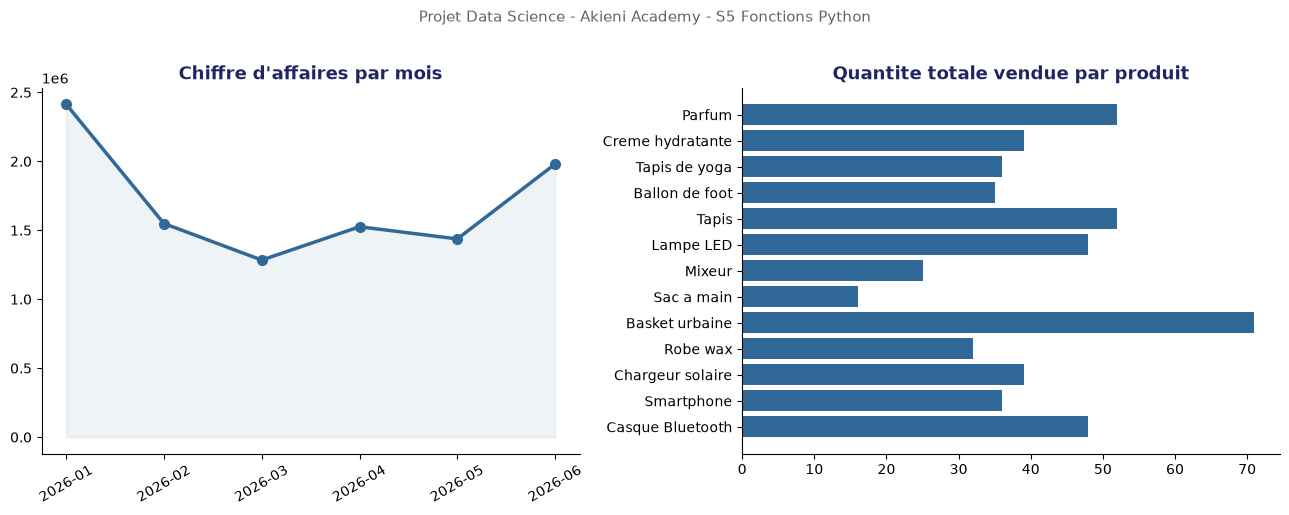

In [21]:
NAVY = "#1E2761"
BLUE = "#306998"
YELLOW = "#FFD43B"

plt.rcParams["font.family"] = "DejaVu Sans"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

# --- Graphique 1 : CA par mois (fonction intermediaire) ---
ax = axes[0]
try:
    mois_uniques, ca_mois = chiffre_affaires_par_mois(dates, quantites, prix_unitaires)
    if not mois_uniques:
        raise ValueError("liste vide")
    # on trie les mois par ordre chronologique pour un graphique lisible
    paires_triees = sorted(zip(mois_uniques, ca_mois))
    mois_tries = [p[0] for p in paires_triees]
    ca_tries = [p[1] for p in paires_triees]
    ax.plot(mois_tries, ca_tries, marker="o", color=BLUE, linewidth=2.5, markersize=7)
    ax.fill_between(mois_tries, ca_tries, color=BLUE, alpha=0.08)
    ax.set_title("Chiffre d'affaires par mois", fontsize=13, fontweight="bold", color=NAVY)
    ax.tick_params(axis="x", rotation=30)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
except Exception:
    ax.text(0.5, 0.5, "Terminez chiffre_affaires_par_mois()\npour debloquer ce graphique",
            ha="center", va="center", fontsize=12, color=NAVY, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])

# --- Graphique 2 : quantite totale vendue par produit (fonction debutant) ---
ax = axes[1]
try:
    totaux_catalogue = [quantite_totale_produit(produits, quantites, nom) for nom in noms_produits_catalogue]
    if sum(totaux_catalogue) == 0:
        raise ValueError("aucune quantite calculee")
    ax.barh(noms_produits_catalogue, totaux_catalogue, color=BLUE)
    ax.set_title("Quantite totale vendue par produit", fontsize=13, fontweight="bold", color=NAVY)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
except Exception:
    ax.text(0.5, 0.5, "Terminez quantite_totale_produit()\npour debloquer ce graphique",
            ha="center", va="center", fontsize=12, color=NAVY, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Projet Data Science - Akieni Academy - S5 Fonctions Python",
             fontsize=11, color="#5B6572", y=1.02)
plt.tight_layout()
plt.savefig("mon_graphique_ventes.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Synthese *(a completer)*

Repondez en 3-4 phrases, en francais, directement dans cette cellule :

1. Quel est le produit le plus vendu ?
2. Le chiffre d'affaires progresse-t-il ou baisse-t-il sur la periode ?
3. Combien de commandes ont ete detectees avec une quantite manquante ou un prix a 0 ?
   Comment vos fonctions ont-elles gere ce cas ?
4. Quelle fonction avez-vous trouvee la plus difficile a ecrire, et pourquoi ?

*(Double-cliquez ici pour ecrire votre reponse...)*

- 1. Le produit le plus vendu a été les basket urbain avec environ 70 unités vendu
- 2. Sur la période 2026-01 à 2026-06 le chiffre d'affaire passe de 2.5 à 2.0 avec un taux de croissance négative de  - 35.83 il y'a diminution.
- 3. Il y'a deux commandes qui présentent des quantités manquantes. Les fonctions les ont ignoré
- 4. Pratiquement la totalité, étant débutant même les plus simples se presentent assez complexe. Mais le fait est que je m'adapte.


---
## 8. Partagez votre projet sur LinkedIn

C'est l'occasion de montrer ce que vous savez deja faire apres seulement 5 semaines de Python !

### Etapes
1. Executez la cellule de la section 6 : un fichier **mon_graphique_ventes.png** est sauvegarde
   a cote de ce notebook (ou faites une capture d'ecran du graphique).
2. Publiez ce visuel sur LinkedIn avec le texte ci-dessous (a adapter avec vos propres mots).
3. Identifiez **Akieni Academy** et utilisez les hashtags proposes.

### Modele de publication

> Semaine 5 de mon parcours Data Science chez Akieni Academy : les fonctions Python !
>
> Cette semaine j'ai applique def, return, les boucles, les conditions et la gestion
> des erreurs avec try/except sur un vrai mini-projet : l'analyse des ventes d'une
> boutique en ligne, uniquement avec des listes Python.
>
> En quelques fonctions reutilisables, j'ai pu calculer le chiffre d'affaires, identifier le
> produit le plus vendu et gerer des donnees manquantes : un vrai premier pas vers
> le metier de Data Analyst / Data Scientist !
>
> #DataScience #Python #AkieniAcademy #Apprentissage #DataAnalyst

### Avant de publier
- [ ] Verifiez qu'aucune donnee sensible ou personnelle n'apparait (donnees simulees ici, donc ok)
- [ ] Relisez votre texte
- [ ] Taguez Akieni Academy et vos camarades de promo si vous le souhaitez
